In [ ]:
 # Data Analysis and visualization tools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
from sklearn.ensemble import ExtraTreesClassifier
#statistics tools
import statsmodels.api as sm
import scipy.stats as st
from scipy.stats import shapiro, mannwhitneyu, chi2_contingency

#scikit learn framework
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ireland task/3 dataset task/online_shoppers_intention.csv')



In [ ]:
data.shape

(12330, 18)

In [ ]:
# @title Default title text
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<Axes: ylabel='PageValues'>

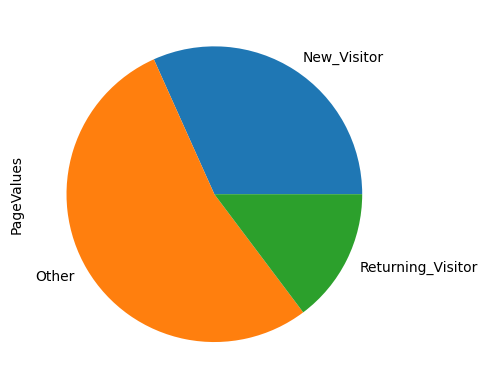

In [ ]:
# @title Average Page Value by Visitor Type

data.groupby('VisitorType')['PageValues'].mean().plot(kind='pie')

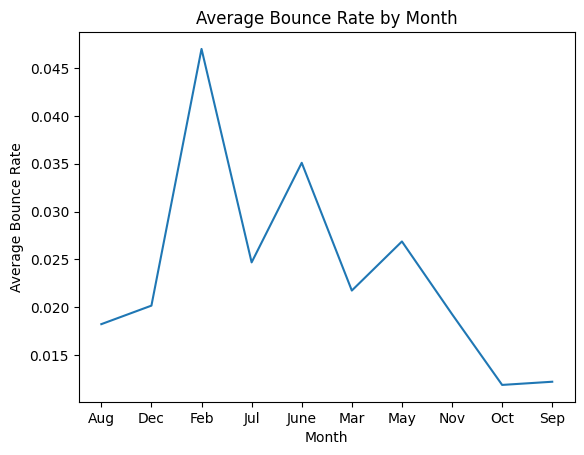

In [ ]:
# @title Average Bounce Rate by Month

import matplotlib.pyplot as plt
plt.plot(data.groupby('Month')['BounceRates'].mean())
plt.title('Average Bounce Rate by Month')
plt.ylabel('Average Bounce Rate')
_ = plt.xlabel('Month')

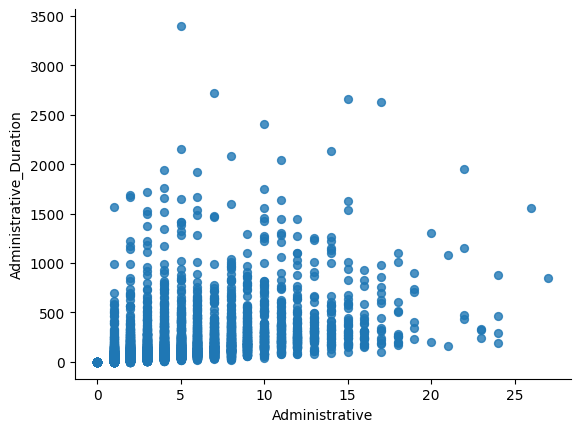

In [ ]:
# @title Administrative vs Administrative_Duration

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='Administrative', y='Administrative_Duration', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

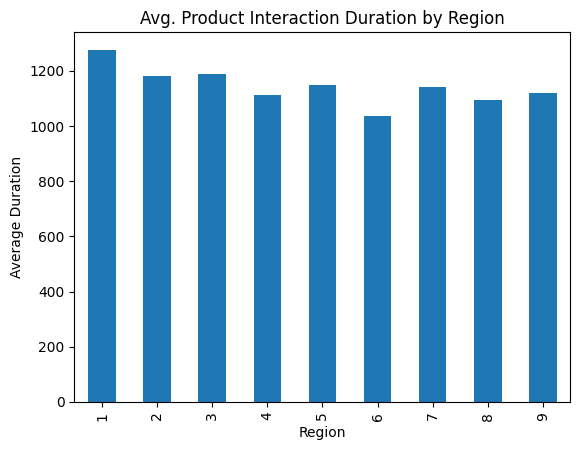

In [ ]:
# @title Avg. Product Interaction Duration by Region

import matplotlib.pyplot as plt

# Group data by region and calculate average product interaction duration
avg_product_interaction_duration_region = data.groupby('Region')['ProductRelated_Duration'].mean()

# Create the bar chart
avg_product_interaction_duration_region.plot(kind='bar')
plt.title('Avg. Product Interaction Duration by Region')
plt.ylabel('Average Duration')
plt.show()

<ipython-input-103-1f6e442ac7f1>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data, x='Administrative', y='Revenue', inner='box', palette='Dark2')


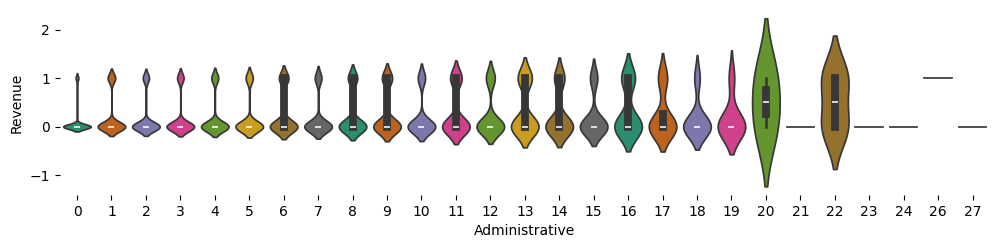

In [ ]:
# @title Revenue vs Administrative

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(data['Revenue'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='Administrative', y='Revenue', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<ipython-input-104-b395831aa05f>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data, x='Administrative', y='Weekend', inner='box', palette='Dark2')


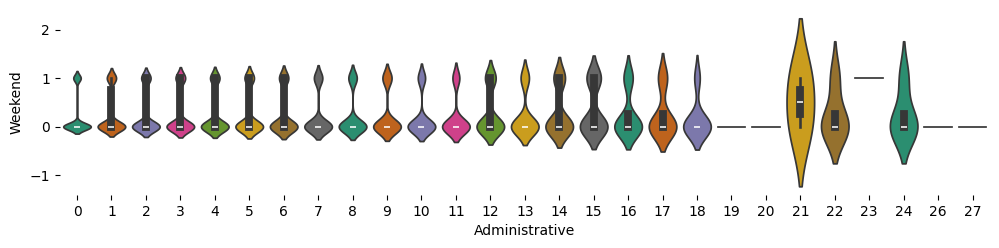

In [ ]:
# @title Weekend vs Administrative

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(data['Weekend'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='Administrative', y='Weekend', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

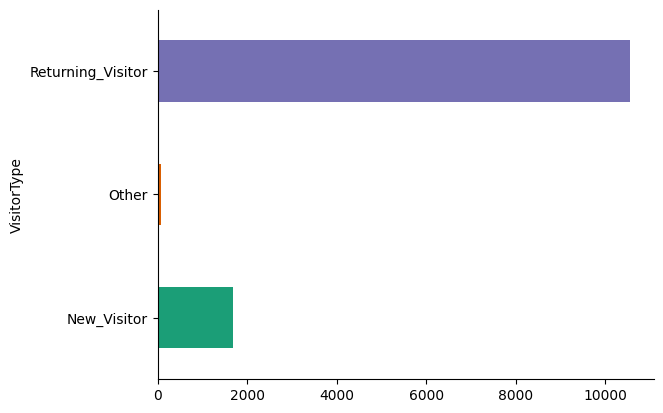

In [ ]:
# @title VisitorType

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('VisitorType').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-106-7a0a3a776eea>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data, x='Administrative', y='VisitorType', inner='box', palette='Dark2')


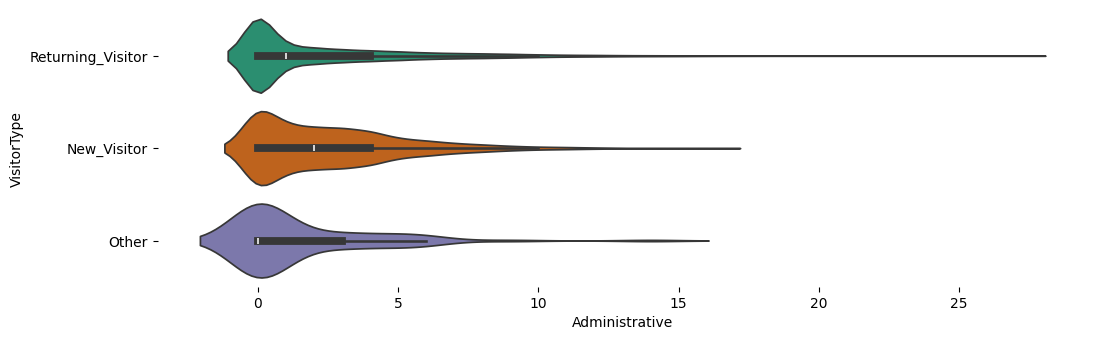

In [ ]:
# @title VisitorType vs Administrative

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(data['VisitorType'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='Administrative', y='VisitorType', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

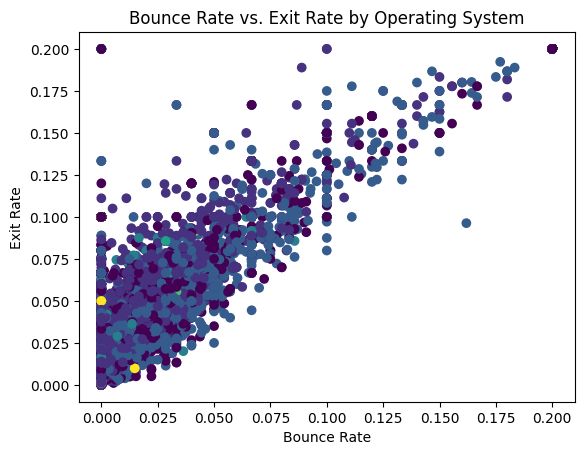

In [ ]:
# @title Bounce Rate vs. Exit Rate by Operating System

import matplotlib.pyplot as plt

# Create the scatter plot
plt.scatter(data['BounceRates'], data['ExitRates'], c=data['OperatingSystems'])
plt.title('Bounce Rate vs. Exit Rate by Operating System')
plt.xlabel('Bounce Rate')
plt.ylabel('Exit Rate')
plt.show()

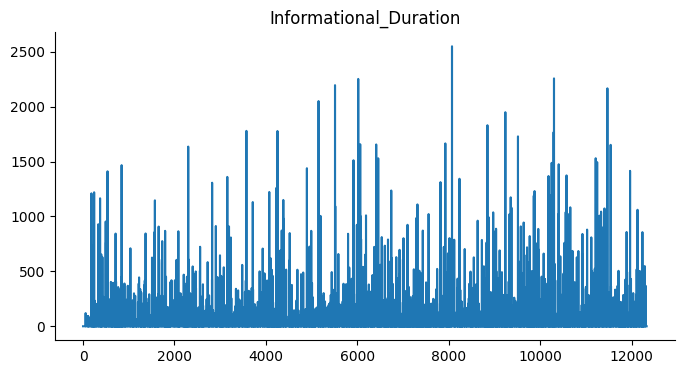

In [ ]:
# @title Informational_Duration

from matplotlib import pyplot as plt
data['Informational_Duration'].plot(kind='line', figsize=(8, 4), title='Informational_Duration')
plt.gca().spines[['top', 'right']].set_visible(False)

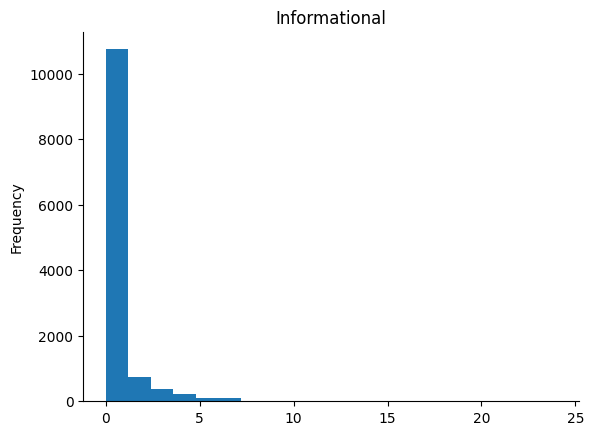

In [ ]:
# @title Informational

from matplotlib import pyplot as plt
data['Informational'].plot(kind='hist', bins=20, title='Informational')
plt.gca().spines[['top', 'right',]].set_visible(False)

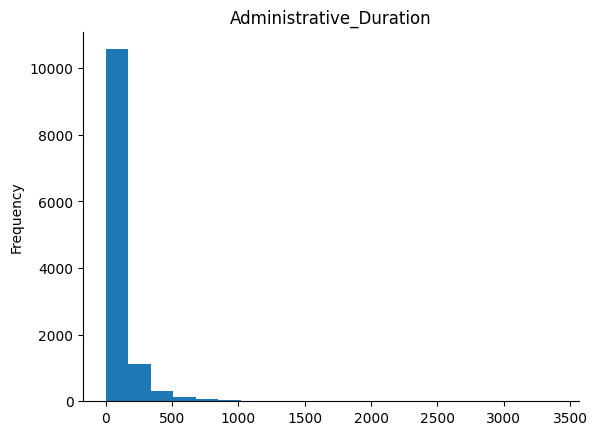

In [ ]:
# @title Administrative_Duration

from matplotlib import pyplot as plt
data['Administrative_Duration'].plot(kind='hist', bins=20, title='Administrative_Duration')
plt.gca().spines[['top', 'right',]].set_visible(False)

<Axes: xlabel='Month', ylabel='BounceRates'>

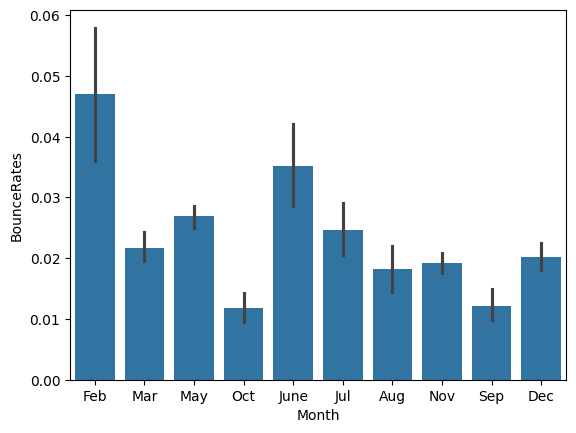

In [ ]:
# @title Bounce Rate by Month

sns.barplot(x = 'Month', y = 'BounceRates', data = data)

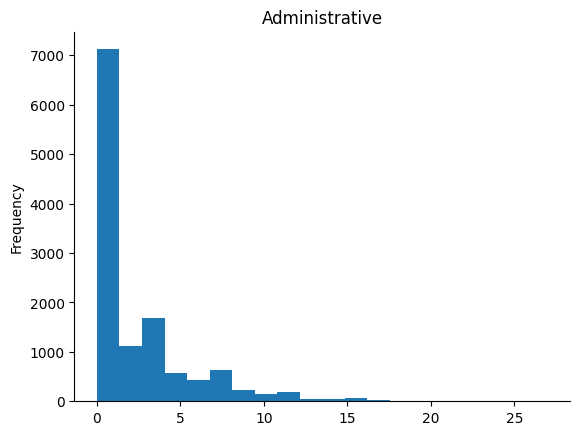

In [ ]:
# @title Administrative

from matplotlib import pyplot as plt
data['Administrative'].plot(kind='hist', bins=20, title='Administrative')
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-113-8b6bc7ae30aa>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=data, order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], palette=colors)


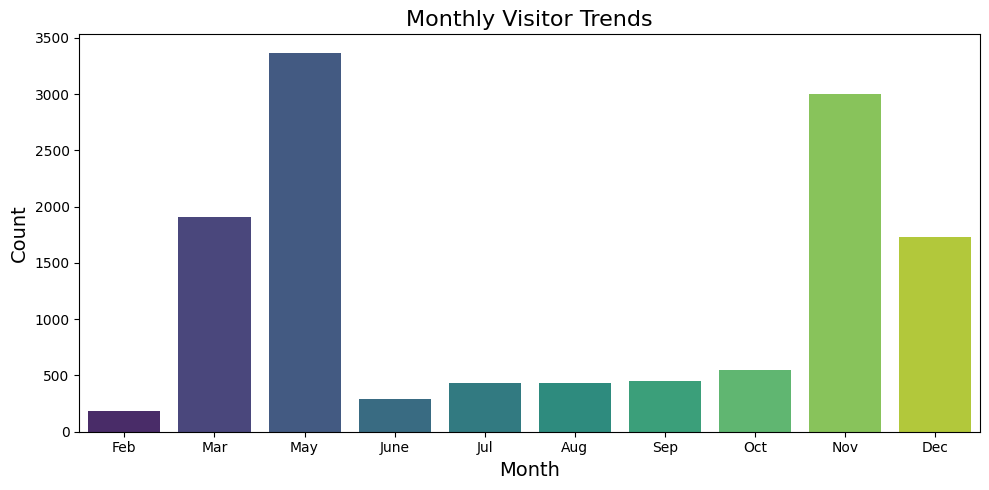

In [ ]:
colors = sns.color_palette("viridis", len(data['Month'].unique()))

# Create a countplot
plt.figure(figsize=(10, 5))
sns.countplot(x='Month', data=data, order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], palette=colors)

# Set title and labels
plt.title('Monthly Visitor Trends', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
Month_result = data.groupby(['Month','Revenue'])['Revenue'].agg(['count']).reset_index()
Month_result.head()

,Month,Revenue,count
0,Aug,False,357
1,Aug,True,76
2,Dec,False,1511
3,Dec,True,216
4,Feb,False,181


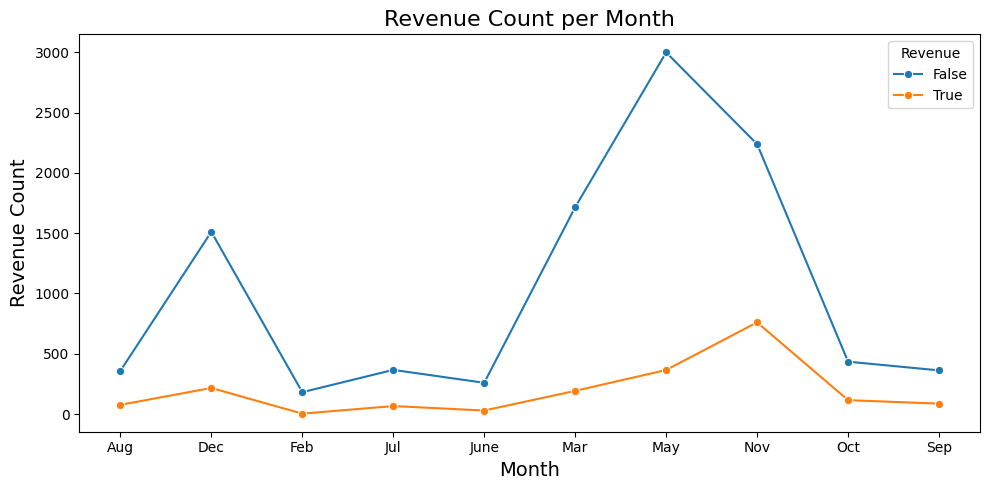

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='Month', y='count', hue='Revenue', marker='o', data=Month_result)

# Set title and labels
plt.title('Revenue Count per Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Revenue Count', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()

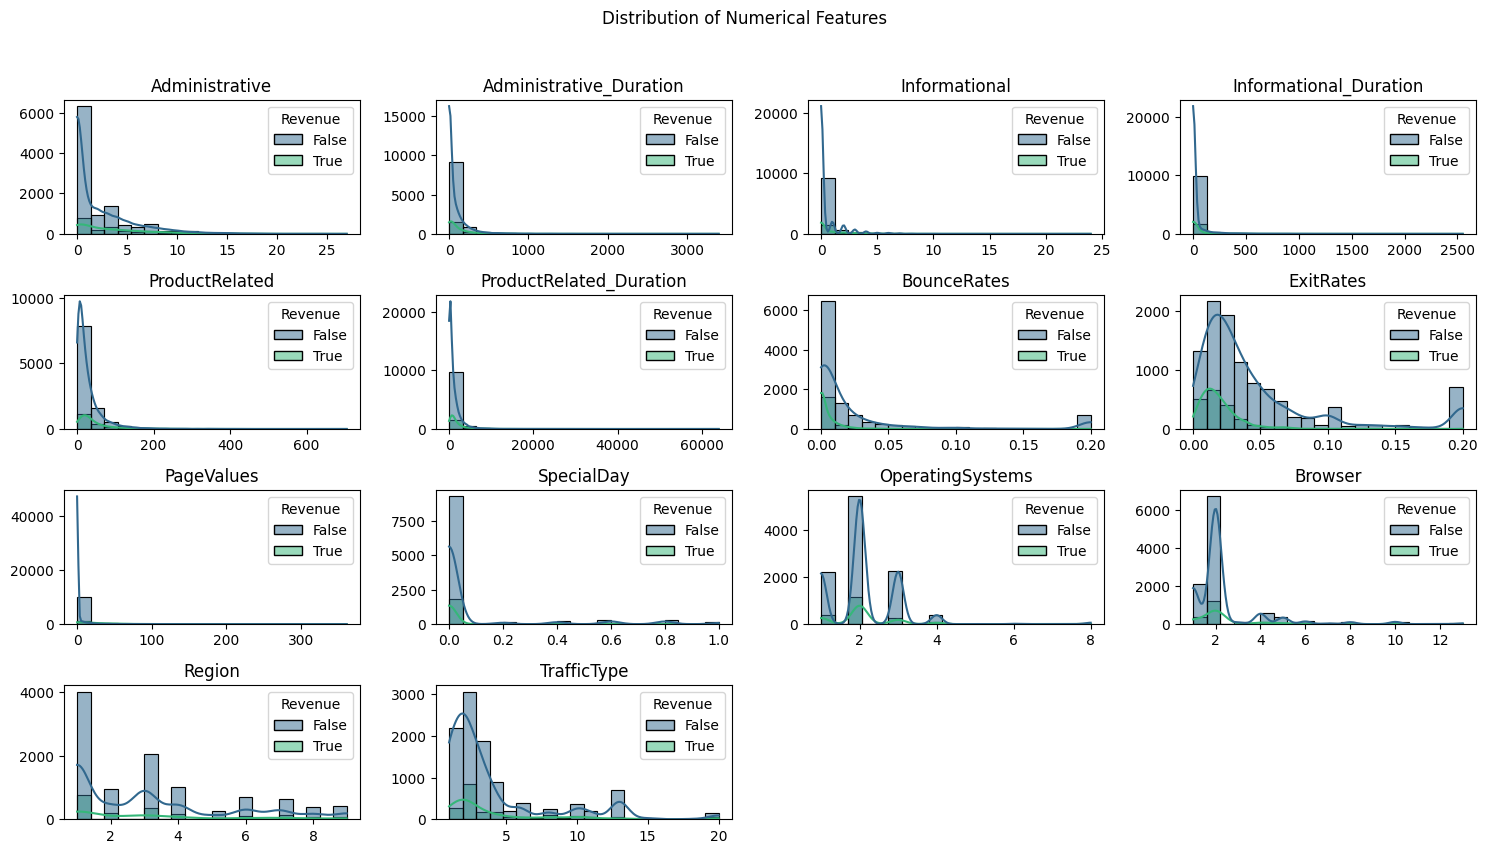

In [ ]:
# Selecting numerical features
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Set up the layout for subplots
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features', y=1.02)

# Plotting histograms for each numerical feature
for i, feature in enumerate(numerical_features):
    row, col = i // 4, i % 4
    sns.histplot(data, x=feature, bins=20, kde=True, ax=axes[row, col], hue='Revenue', palette='viridis')
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('')

# Remove empty subplots
for i in range(len(numerical_features), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

# Adjust layout
plt.tight_layout()

plt.show()

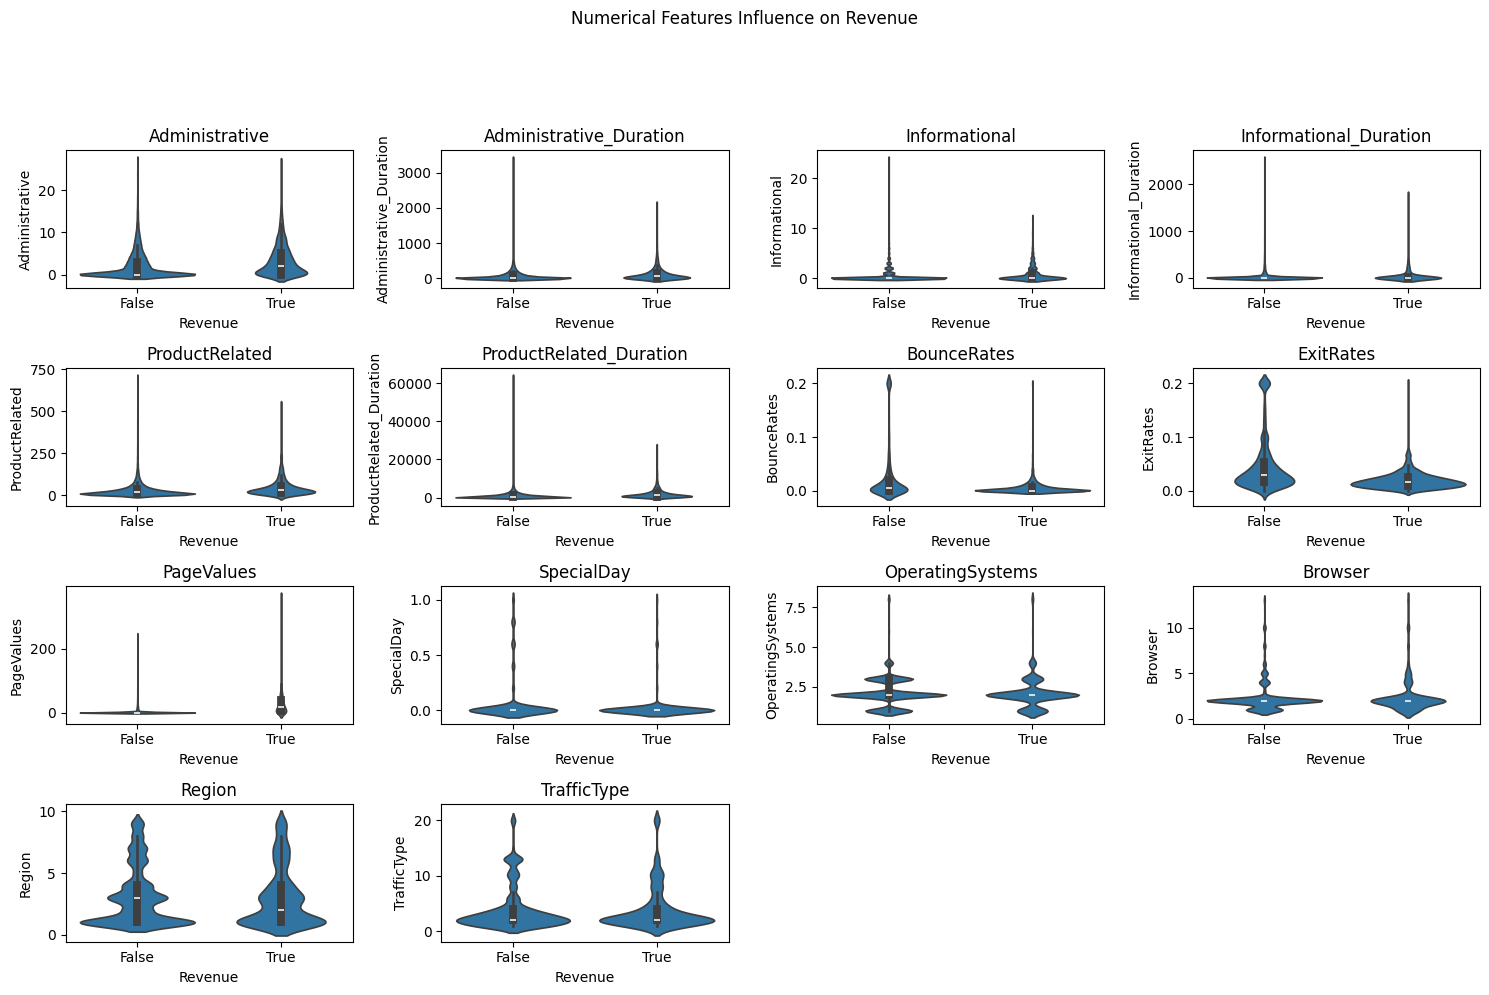

In [ ]:
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Set up the layout for subplots
plt.figure(figsize=(15, 10))
plt.suptitle('Numerical Features Influence on Revenue', y=1.02)

# Plotting boxplots for each numerical feature against Revenue
for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i+1)
    sns.violinplot(x='Revenue', y=col, data=data)
    plt.title(col)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

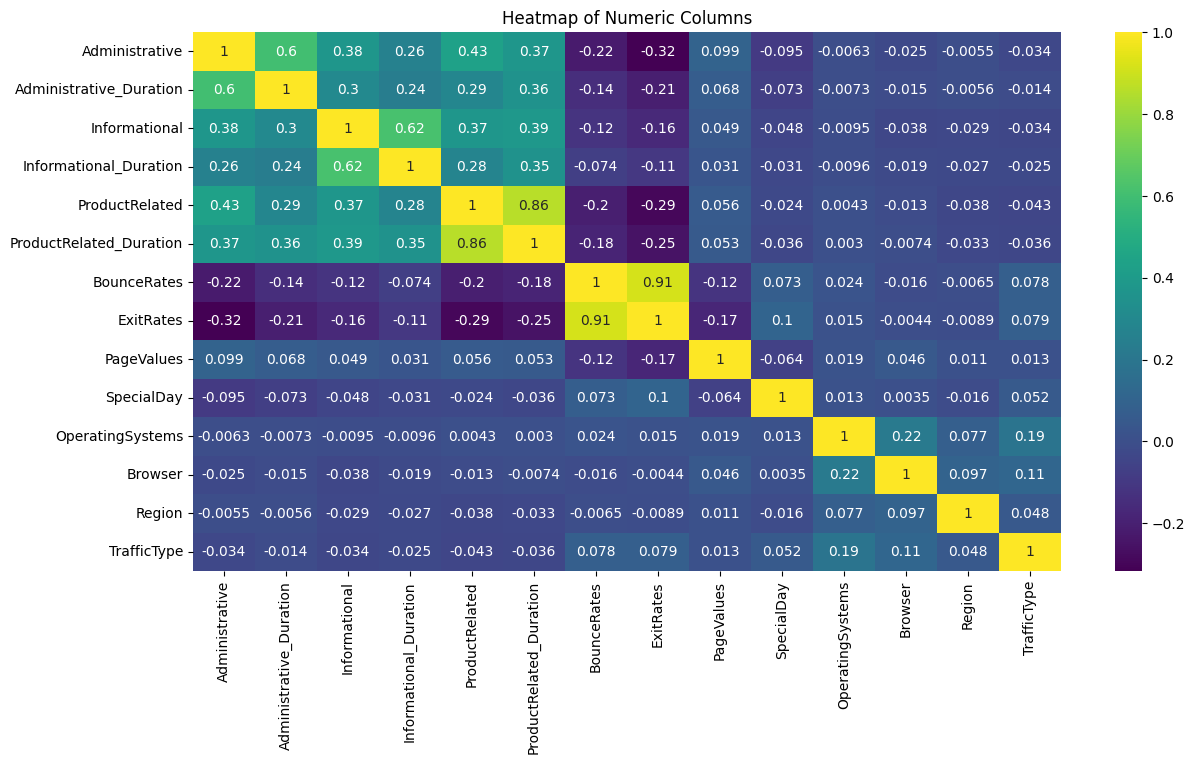

In [ ]:
numeric_columns = data.select_dtypes(include='number')

plt.figure(figsize=(14, 7))

plt.title("Heatmap of Numeric Columns")

sns.heatmap(data=numeric_columns.corr(), annot=True, cmap='viridis')

plt.show()

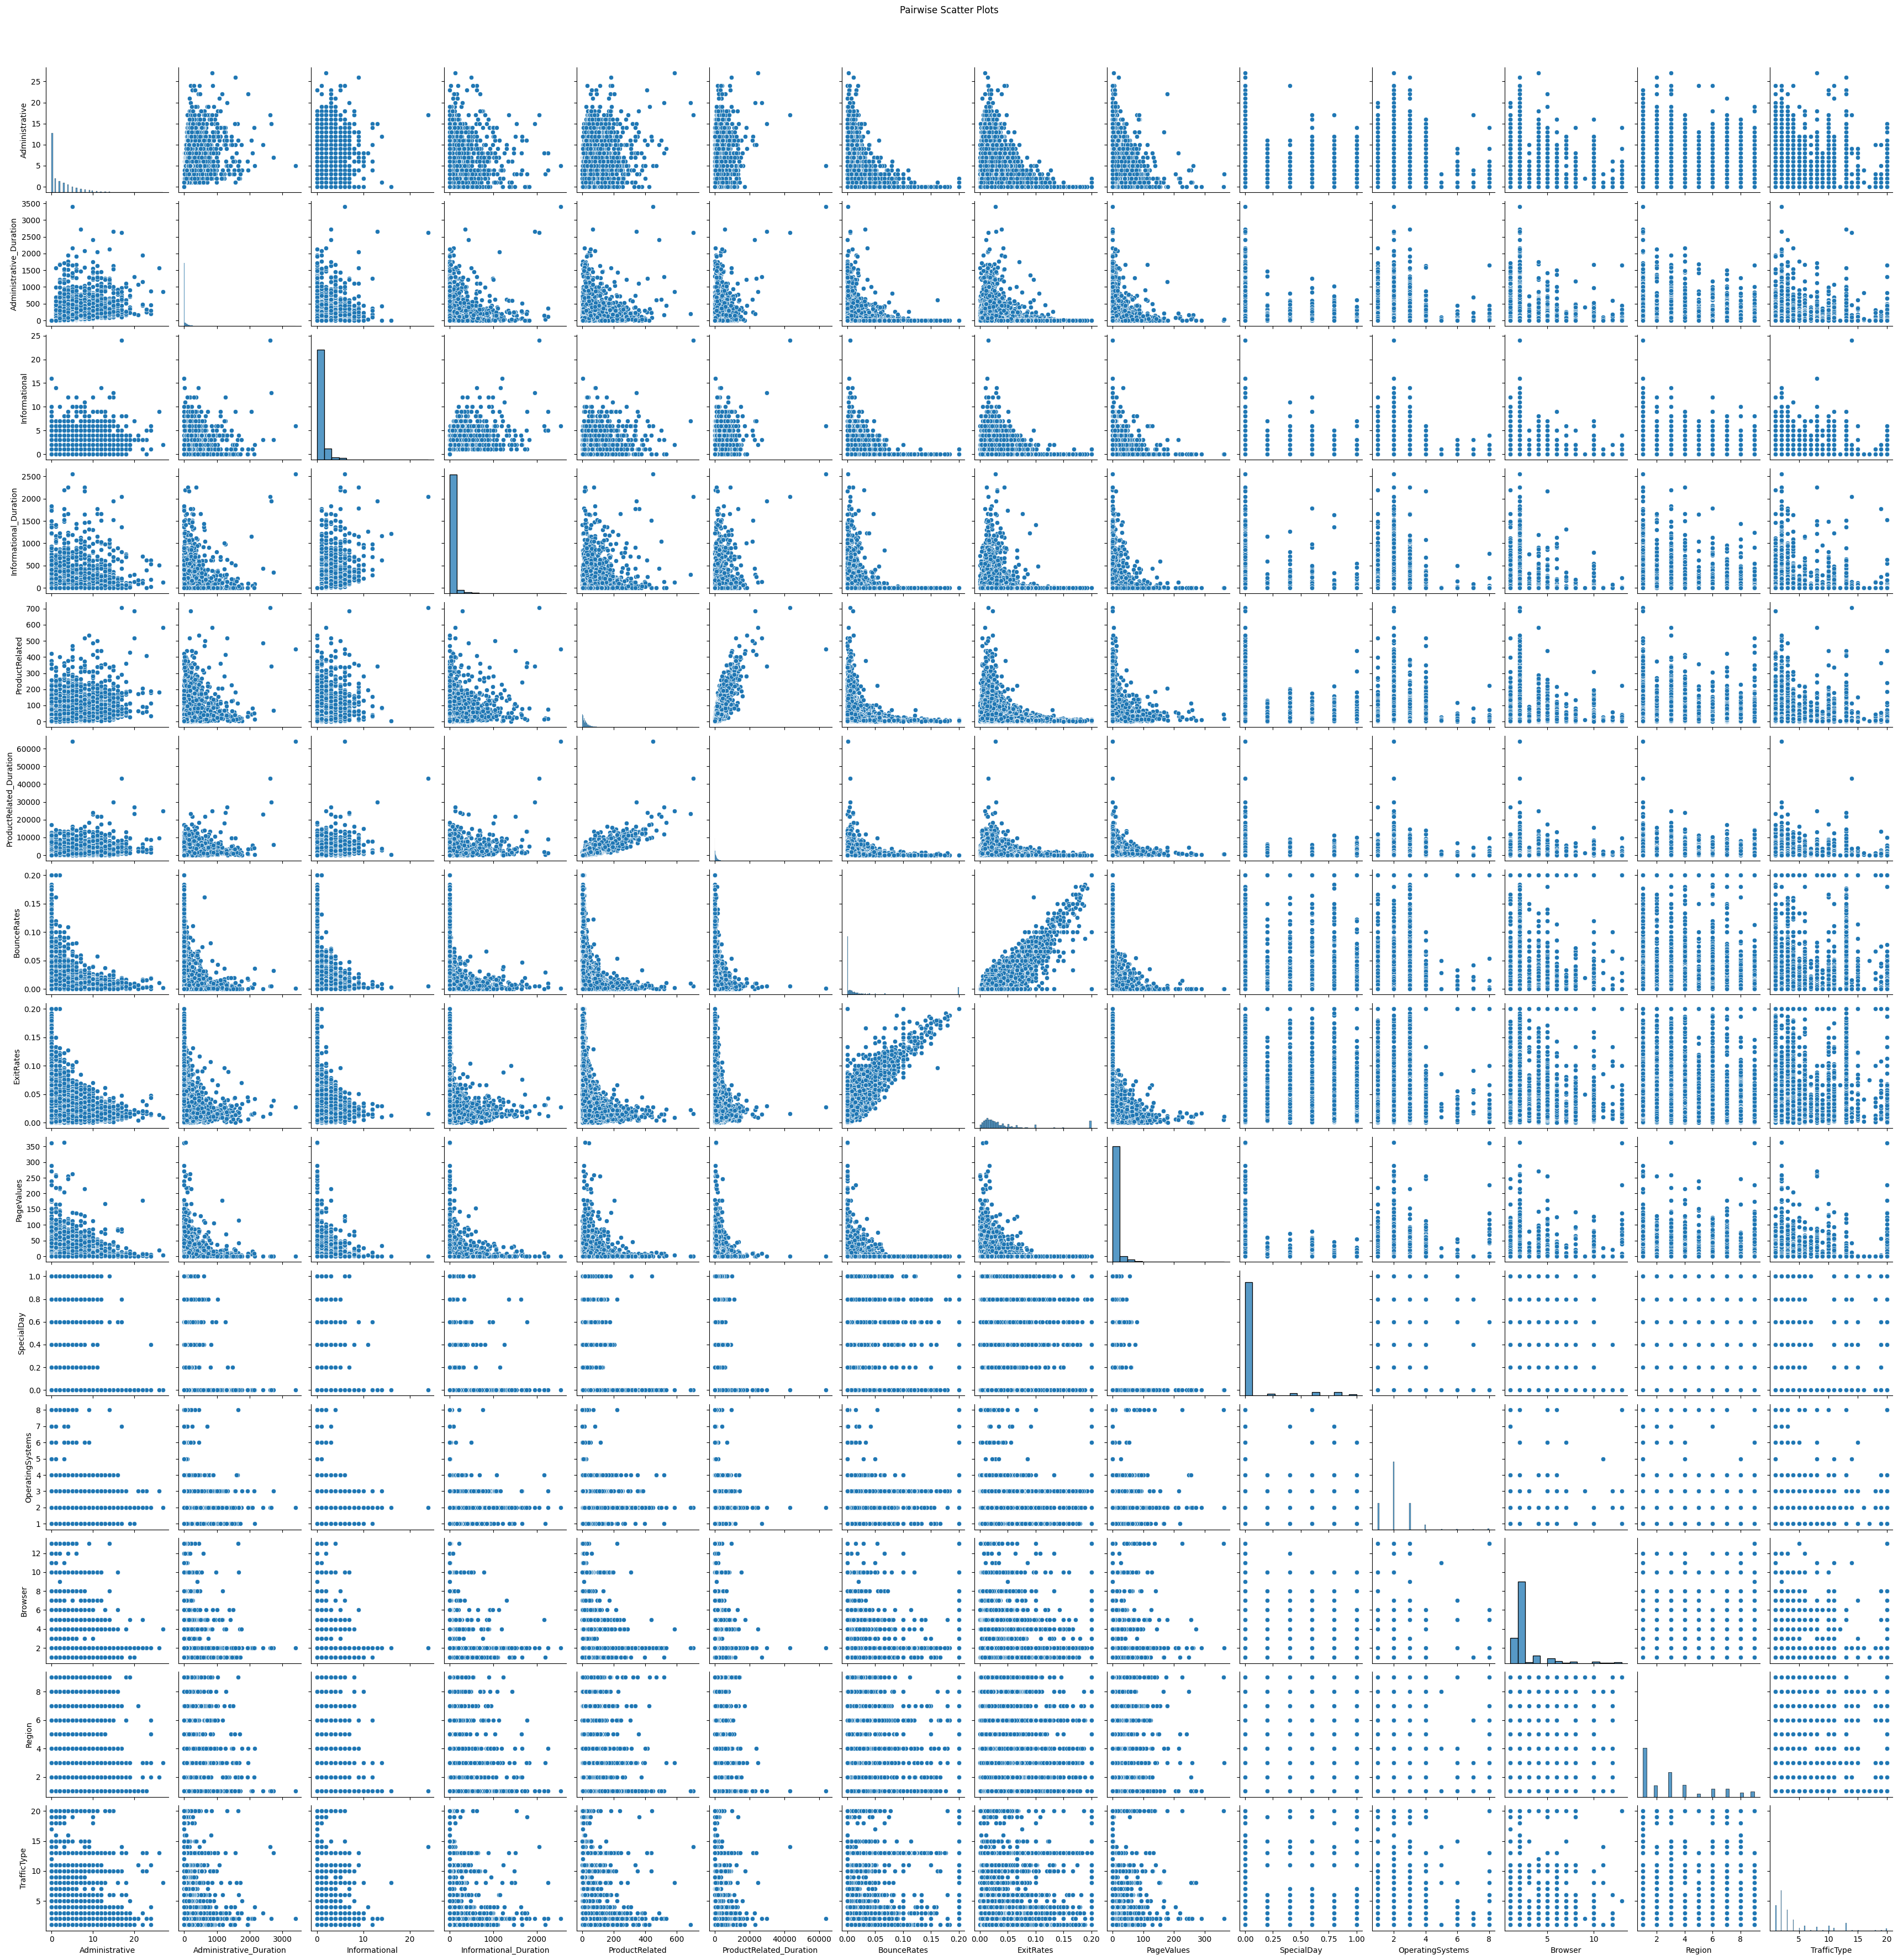

In [ ]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.pairplot(numeric_data)
plt.suptitle('Pairwise Scatter Plots', y=1.02)
plt.show()

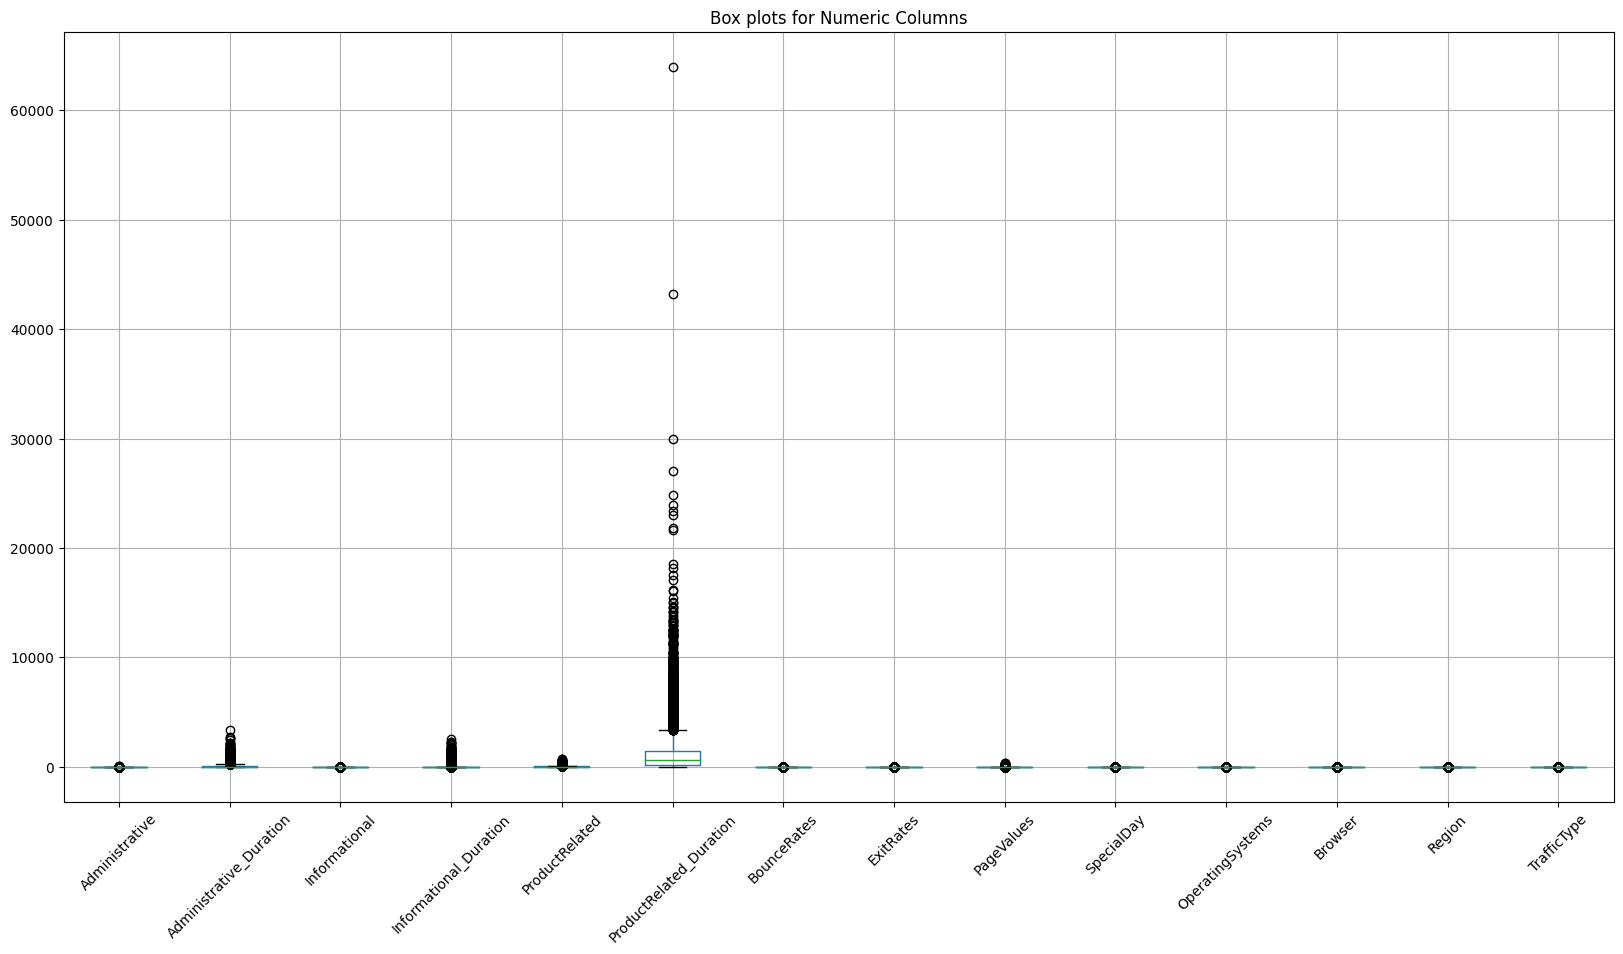

In [ ]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])


plt.figure(figsize=(20, 10))
numeric_data.boxplot()
plt.title('Box plots for Numeric Columns')
plt.xticks(rotation=45)
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
data.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [ ]:
data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
data.describe(include = 'object')

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [ ]:
data.describe(include = 'bool')

,Weekend,Revenue
count,12330,12330
unique,2,2
top,False,False
freq,9462,10422


In [ ]:
data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [ ]:
missing_percentage = data.isnull().sum()/data.shape[0]
print(missing_percentage)

Administrative             0.0
Administrative_Duration    0.0
Informational              0.0
Informational_Duration     0.0
ProductRelated             0.0
ProductRelated_Duration    0.0
BounceRates                0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                 0.0
Month                      0.0
OperatingSystems           0.0
Browser                    0.0
Region                     0.0
TrafficType                0.0
VisitorType                0.0
Weekend                    0.0
Revenue                    0.0
dtype: float64


In [ ]:
# Imputing Missing Values with 0
data.fillna(0, inplace = True)

#checking the no. of null values after imputing
data.isnull().sum().sum()

0

In [ ]:
data.duplicated().value_counts()

False    12205
True       125
Name: count, dtype: int64

In [ ]:
data_cleaned = data.drop_duplicates()


In [ ]:
print(data_cleaned.shape)

(12205, 18)


In [ ]:
duplicated_rows = data[data.duplicated()]

# Print the duplicated rows
print(duplicated_rows)

       Administrative  Administrative_Duration  Informational  \
158                 0                      0.0              0   
159                 0                      0.0              0   
178                 0                      0.0              0   
418                 0                      0.0              0   
456                 0                      0.0              0   
...               ...                      ...            ...   
11934               0                      0.0              0   
11938               0                      0.0              0   
12159               0                      0.0              0   
12180               0                      0.0              0   
12185               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
158                       0.0               1                      0.0   
159                       0.0               1                      0.0 

In [ ]:
from sklearn import preprocessing

# Loop over each column in the DataFrame where dtype is 'object'
for col in data.select_dtypes(include=['object','bool']).columns:

    # Print the column name and the unique values
    print(f"{col}: {data[col].unique()}")

# Loop over each column in the DataFrame where dtype is 'object'
for col in data.select_dtypes(include=['object','bool']).columns:
    # Handle missing values (replace with a default value or drop rows)
    data[col].fillna('unknown', inplace=True)

    # Convert all values to strings
    data[col] = data[col].astype(str)

    # Initialize a LabelEncoder object
    label_encoder = preprocessing.LabelEncoder()

    # Fit the encoder to the unique values in the column
    label_encoder.fit(data[col].unique())

    # Transform the column using the encoder
    data[col] = label_encoder.transform(data[col])

    # Print the column name and the unique encoded values
    print(f"{col}: {data[col].unique()}")

Month: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
VisitorType: ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend: [False  True]
Revenue: [False  True]
Month: [2 5 6 8 4 3 0 7 9 1]
VisitorType: [2 0 1]
Weekend: [0 1]
Revenue: [0 1]


In [ ]:
data.corr()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,0.048560,-0.006347,-0.025035,-0.005487,-0.033561,-0.025820,0.026417,0.138917
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,0.029061,-0.007343,-0.015392,-0.005561,-0.014376,-0.023940,0.014990,0.093587
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,0.019743,-0.009527,-0.038235,-0.029169,-0.034491,0.055828,0.035785,0.095200
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,0.005987,-0.009579,-0.019285,-0.027144,-0.024675,0.044677,0.024078,0.070345
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,0.070299,0.004290,-0.013146,-0.038122,-0.043064,0.126656,0.016092,0.158538
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,0.061186,0.002976,-0.007380,-0.033091,-0.036377,0.119329,0.007311,0.152373
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,-0.023763,0.023823,-0.015772,-0.006485,0.078286,0.135536,-0.046514,-0.150673
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,-0.039049,0.014567,-0.004442,-0.008907,0.078616,0.179144,-0.062587,-0.207071
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,0.021780,0.018508,0.045592,0.011315,0.012532,-0.111228,0.012002,0.492569
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,0.079341,0.012652,0.003499,-0.016098,0.052301,0.085557,-0.016767,-0.082305


In [ ]:
# Splitting dependent and independent variables(columns)
y = data['Revenue']
x = data.drop(['Revenue'], axis = 1)

# checking the shapes
print("Shape of x: ", x.shape)
print("Shape of y: ", y.shape)

Shape of x:  (12330, 17)
Shape of y:  (12330,)


In [ ]:
# Splitting of the Data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =  0.3, random_state = 0)

# checking the shapes

print("Shape of x_train :", x_train.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of x_test :", x_test.shape)
print("Shape of y_test :", y_test.shape)

Shape of x_train : (8631, 17)
Shape of y_train : (8631,)
Shape of x_test : (3699, 17)
Shape of y_test : (3699,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=1000, random_state=1)
rf.fit(x_train, y_train)

# Make predictions on the test set and evaluate model performance
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

Accuracy: 0.8948364422816978
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3077
           1       0.75      0.56      0.64       622

    accuracy                           0.89      3699
   macro avg       0.83      0.76      0.79      3699
weighted avg       0.89      0.89      0.89      3699



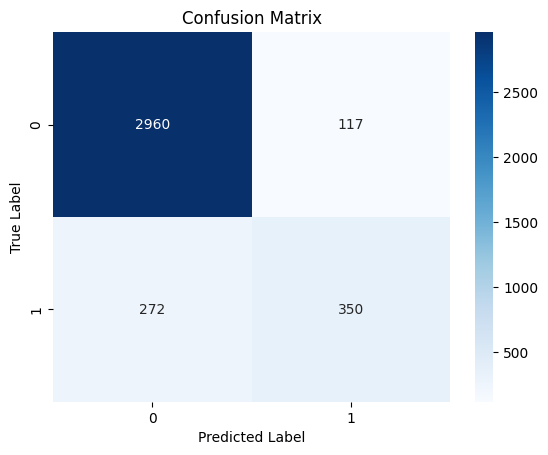

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

Accuracy: 0.8523925385239254
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      3077
           1       0.64      0.28      0.39       622

    accuracy                           0.85      3699
   macro avg       0.75      0.62      0.65      3699
weighted avg       0.83      0.85      0.83      3699



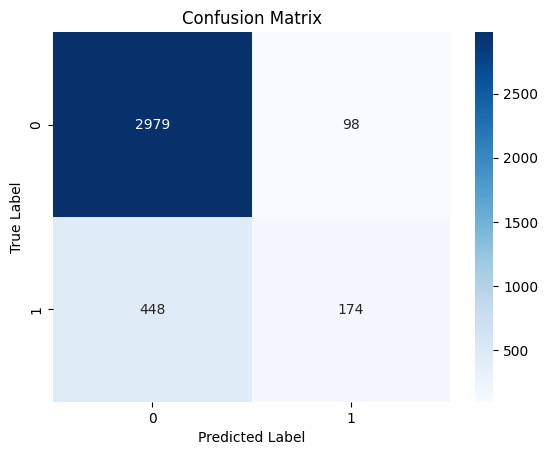

In [ ]:
from sklearn.metrics import confusion_matrix
knn = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
sns.heatmap(knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()